<img src="https://github.com/nicholasmetherall/digital-earth-pacific-macblue-activities/blob/main/attachments/images/DE_Pacific_banner.JPG?raw=true" width="900"/>
Figure 1.1.a. Jupyter environment + Python notebooks

### NDTI analyses

Some inputs from the following notebooks: https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Real_world_examples/Wetland_turbidity.html

In [1]:
from pystac_client import Client
from dask.distributed import Client as DaskClient
from odc.stac import load, configure_s3_access
import rasterio as rio
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import folium
import utils
from utils import load_data
# from utils import mask_and_scale
from sklearn.ensemble import RandomForestClassifier
import odc.geo.xr
import rioxarray
import matplotlib.pyplot as plt
from datetime import datetime
from odc.stac import load


Define catalogue

In [2]:
catalogue = "https://earth-search.aws.element84.com/v1"
client = Client.open(catalogue)

In [3]:
# #Navua
# min_lat = -18.277530
# min_lon = 178.144327
# max_lat = -18.252355
# max_lon = 178.171476

# -18.279530, 178.142327
# -18.254355, 178.169476

# bbox = [min_lon, min_lat, max_lon, max_lat]

In [4]:
# # #Suva
# min_lat = -18.215062
# min_lon = 178.403377
# max_lat = -18.086312
# max_lon = 178.604283


# bbox = [min_lon, min_lat, max_lon, max_lat]

In [5]:
# #PNG
# min_lat = -8.8464615
# min_lon = 142.018333
# max_lat = -7.9750438
# max_lon = 143.911034


# bbox = [min_lon, min_lat, max_lon, max_lat]

In [6]:
# #Solomon Islands
# min_lat =  -9.427281
# min_lon =  160.01445
# max_lat = -9.3973759
# max_lon = 160.040215


# bbox = [min_lon, min_lat, max_lon, max_lat]

In [7]:
#PNG 2 bootlessbay
# min_lat = -9.5172643
# min_lon = 147.272733
# max_lat = -9.4927668
# max_lon = 147.292422


# bbox = [min_lon, min_lat, max_lon, max_lat]

In [8]:
# #Ra
# min_lat = -17.515442
# min_lon = 178.188805
# max_lat = -17.367698
# max_lon = 178.327742
 
 
# bbox = [min_lon, min_lat, max_lon, max_lat]

In [9]:
# #Vusasivo
# min_lat = -16.574914
# min_lon = 179.756094
# max_lat = -16.563194
# max_lon = 179.761568
 
 
# bbox = [min_lon, min_lat, max_lon, max_lat]

In [10]:
# #Efate
# min_lon = 168.38677
# min_lat = -17.53851
# max_lon = 168.44753
# max_lat = -17.50726

# bbox = [min_lon, min_lat, max_lon, max_lat]

In [11]:
#geojson
gdf = gpd.read_file("serua.geojson")
#version = "malekula_joined_model_mask_test3"
#gdf = gpd.read_file("training-data/Alluvium_vu_malekula_13022025.geojson")
gdf = gdf.to_crs("EPSG:4326")
min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
bbox = [min_lon, min_lat, max_lon, max_lat]


In [12]:
gdf.explore()

In [13]:
date_start = "2017-01"

In [14]:
# Get the current date and time
date_end = datetime.now()
# Format as a string (e.g., "2025-06-30")
date_end = date_end.strftime("%Y-%m")
print(date_end)

2025-07


In [15]:
datetime = date_start+'/'+date_end
print(datetime)

2017-01/2025-07


Connect to parallel computers for greater computational capacity - note you should only run this line of code once per notebook activity - do not rerun this line

Search through the catalogue - define the cloud cover threshold you want. Try changing 80 to 50 here: `{"lt": 50}},` 

In [16]:
# Search through catalogue for relevant data
items = client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover":{"lt": 35}},
).item_collection()

print(f"Found {len(items)} items")


Found 330 items


In [17]:
selected_item = sorted(items, key=lambda item: item.properties["eo:cloud_cover"])[0]
for asset_key, asset in selected_item.assets.items():
    print(f"{asset_key:<25} - {asset.title}")

aot                       - Aerosol optical thickness (AOT)
blue                      - Blue (band 2) - 10m
coastal                   - Coastal aerosol (band 1) - 60m
granule_metadata          - None
green                     - Green (band 3) - 10m
nir                       - NIR 1 (band 8) - 10m
nir08                     - NIR 2 (band 8A) - 20m
nir09                     - NIR 3 (band 9) - 60m
red                       - Red (band 4) - 10m
rededge1                  - Red edge 1 (band 5) - 20m
rededge2                  - Red edge 2 (band 6) - 20m
rededge3                  - Red edge 3 (band 7) - 20m
scl                       - Scene classification map (SCL)
swir16                    - SWIR 1 (band 11) - 20m
swir22                    - SWIR 2 (band 12) - 20m
thumbnail                 - Thumbnail image
tileinfo_metadata         - None
visual                    - True color image
wvp                       - Water vapour (WVP)
aot-jp2                   - Aerosol optical thickness (AOT)
blue

<font color='blue'>Load your satellite dataset based on your search parameters defined above</font>

In [18]:
data = load(
    items,
    chunks={},
    bbox=bbox,
    groupby="solar_day",
    measurements=[
        "red",
        "green",
        "blue",
        "nir",
        "nir09",
        "swir16",
        "swir22",
        "coastal",
        "rededge1",
        "rededge2",
        "rededge3",
        "scl"
    ]
)

# 0: No Data, 1: Saturated/Defective, 2: Dark Area Pixel, 3: Cloud Shadows, 4: Vegetation, 5: Bare Soils, 6: Water, 7: Unclassiffied, 8: Medium Probability Clouds, 9: High Probability Clouds, 10: Thin Cirrus, 11: Snow or Ice
mask_flags = [1, 3, 8, 9, 10, 11]
#mask_flags = [0, 1, 3, 8, 9, 10, 11]
cloud_mask = ~data.scl.isin(mask_flags)
masked = data.where(cloud_mask).drop_vars("scl")

In [19]:
# # data = utils.load_data
# data = load_data(items, bbox)

<font color='blue'>Set scale and masks and consider the dataset information below including the bands used for analysis:</font>

In [20]:
scaled = (masked.where(masked != 0) * 0.0001).clip(0, 1)

<font color='blue'>Explore the satellite image dataset you have loaded</font>

In [21]:
# time is the number of images over the span of the specified timeframe above (2017 to now)
scaled.isel(time=10).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)

/srv/conda/envs/notebook/lib/python3.10/site-packages/odc/geo/_rgba.py:55: RuntimeWarning: invalid value encountered in cast
  return x.astype("uint8")
/srv/conda/envs/notebook/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


#### Mask land

In [22]:
#### Mask land

mndwi = (scaled["green"]-scaled["swir16"])/(scaled["green"]+scaled["swir16"])
## Moderate land mask
# mndwi_land_mask = mndwi > 0

mndwi_land_mask = mndwi > -0.22

masked_ds = scaled.where(mndwi_land_mask)

masked_ds.isel(time=10).odc.explore(bands=("red", "green", "blue"), vmin=0, vmax=0.3)


In [23]:
ndti = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

Text(0, 0.5, 'Count of pixels')

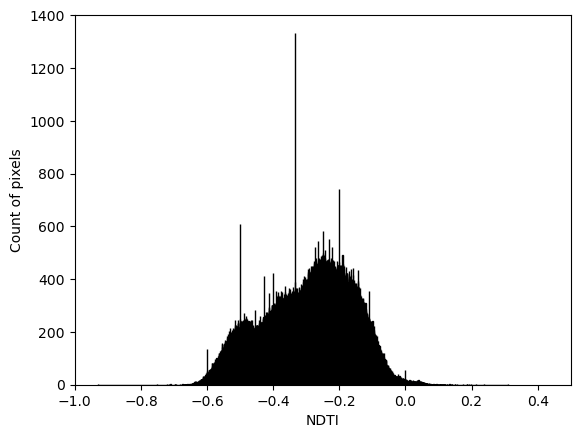

In [24]:
masked_ds["ndti"] = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])

plt.hist(masked_ds.ndti.to_numpy().flatten(), color = 'blue', edgecolor = 'black',
         bins = 8000)
plt.xlim((-1.0,0.5))

# Add labels
plt.xlabel('NDTI')
plt.ylabel('Count of pixels')

(array([1.00000e+00, 7.00000e+00, 2.23970e+04, 1.51344e+05, 2.32987e+05,
        3.31889e+05, 2.10248e+05, 1.77810e+04, 3.01000e+02, 7.00000e+00]),
 array([-0.93103445, -0.8070361 , -0.68303776, -0.55903947, -0.43504113,
        -0.31104279, -0.18704447, -0.06304614,  0.06095219,  0.18495052,
         0.30894884]),
 <BarContainer object of 10 artists>)

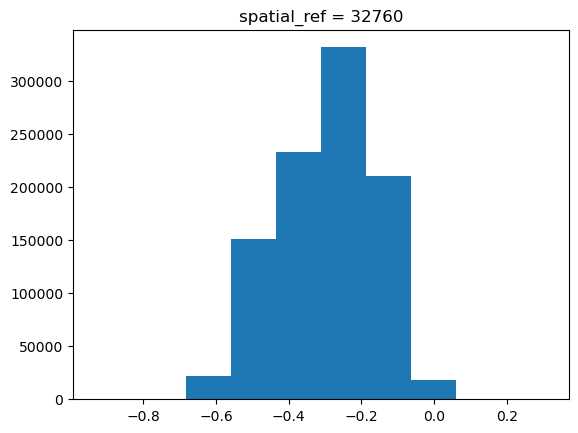

In [25]:
ndti.plot()

In [26]:
ndti.isel(time=10).odc.explore(cmap='BrBG_r', vmin=-0.2, vmax=0.2)

### Compute NDTI over time for each pixel


In [38]:
# #raw ndti
# raw_ndti = masked_ds['ndti'] (dim='time', skipna=True)

ndti_raw = (masked_ds["red"]-masked_ds["green"])/(masked_ds["red"]+masked_ds["green"])
mean_ndti = masked_ds['ndti'].mean(dim=('x', 'y'), skipna=True)


Mask (set to NaN or another value) those pixels where this std exceeds your threshold

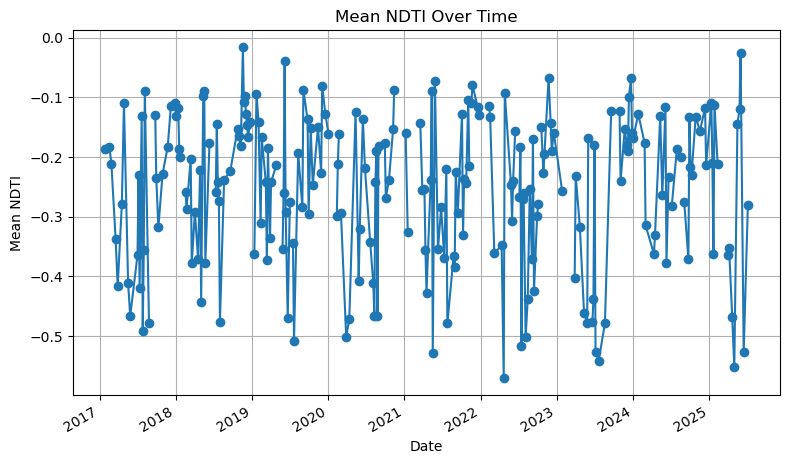

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], mean_ndti, marker='o', linestyle='-')
# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('Mean NDTI')
plt.title('Mean NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [28]:
threshold = 0.05
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
mask_ndti = ndti_raw > threshold
masked_ds = masked_ds.where(~mask_ndti)

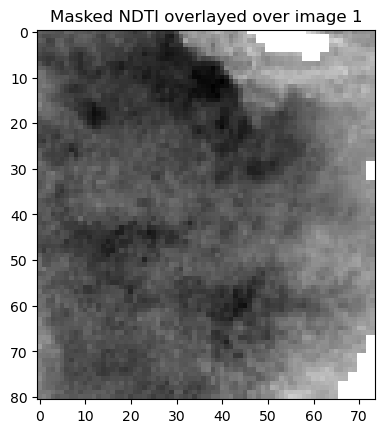

In [29]:
plt.imshow(masked_ds['ndti'].isel(time=0), cmap='gray')
plt.title('Masked NDTI overlayed over image 1')
plt.show()

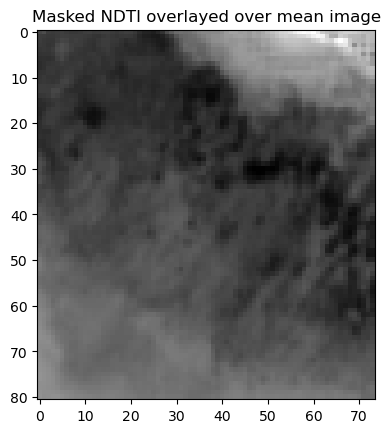

In [30]:
plt.imshow(masked_ds['ndti'].mean(dim='time'), cmap='gray')
plt.title('Masked NDTI overlayed over mean image')
plt.show()

In [40]:
ndti

<xarray.DataArray (time: 252, y: 81, x: 74)> Size: 6MB
dask.array<truediv, shape=(252, 81, 74), dtype=float32, chunksize=(1, 81, 74), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 648B 7.981e+06 7.981e+06 ... 7.981e+06 7.981e+06
  * x            (x) float64 592B 5.877e+05 5.877e+05 ... 5.884e+05 5.884e+05
    spatial_ref  int32 4B 32760
  * time         (time) datetime64[ns] 2kB 2017-01-27T22:30:44.463000 ... 202...

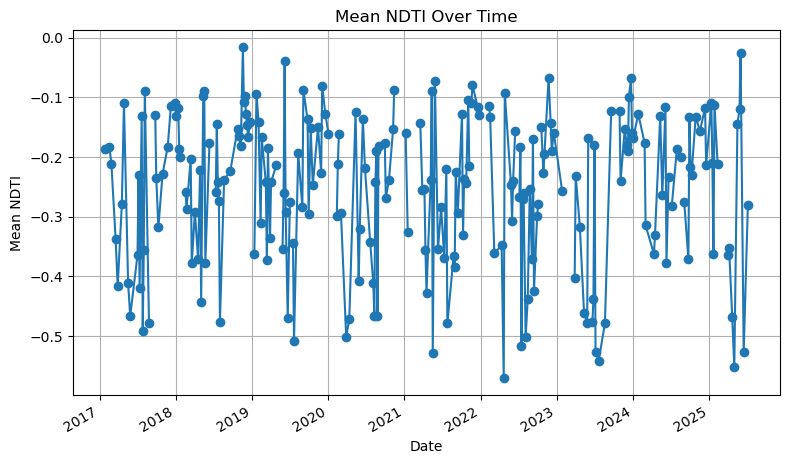

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], mean_ndti, marker='o', linestyle='-')
# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('Mean NDTI')
plt.title('Mean NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

ValueError: x and y can be no greater than 2D, but have shapes (252,) and (252, 81, 74)

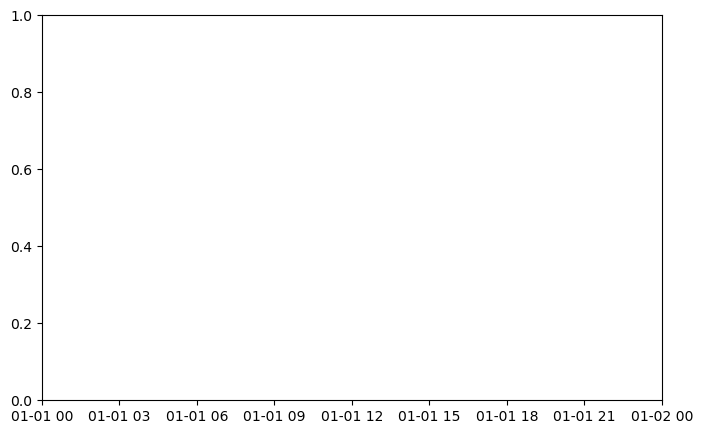

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(masked_ds['time'], ndti, marker='o', linestyle='-')
# plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
plt.xlabel('Date')
plt.ylabel('Mean NDTI')
plt.title('Mean NDTI Over Time')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

In [31]:
# n = len(thresholds)

# fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(4*n, 4))

# for i, thresh in enumerate(thresholds):
#     mask = ndti_raw > thresh  # std_ndti is 2D (y, x)
#     ax = axes[i]
#     im = ax.imshow(mask, cmap='gray')
#     ax.set_title(f'Threshold: {thresh}')
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

threshold_a = 0.25
threshold_b = 0.30

mask_a = ndti_raw > threshold_a  # std_ndti is 2D
mask_b = ndti_raw > threshold_b

# Combine masks: 0 = below both, 1 = above A only, 2 = above both
combined = np.zeros(ndti_raw.shape, dtype=int)
combined[mask_a] = 1
combined[mask_b] = 2

# Custom colormap: 0=white, 1=red, 2=blue (adjust as you wish)
cmap = ListedColormap(['white', 'red', 'blue'])

plt.imshow(combined, cmap=cmap)
plt.title(f'Mask: Red=std>{threshold_a}, Blue=std>{threshold_b}')
plt.axis('off')
plt.show()

KeyboardInterrupt: 

In [ ]:
# mean_ndti = masked_ds['ndti'].mean(dim=('x', 'y'), skipna=True)
# median_ndti = masked_ds['ndti'].median(dim=('x', 'y'), skipna=True)
# std_ndti = masked_ds['ndti'].std(dim=('x', 'y'), skipna=True)
# max_ndti = masked_ds['ndti'].max(dim=('x', 'y'), skipna=True)

In [ ]:
# var_ndti = masked_ds['ndti'].var(dim=('x', 'y'), skipna=True)
# quant90_ndti = masked_ds['ndti'].quantile(0.9, dim=('x', 'y'), skipna=True)

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(masked_ds['time'], mean_ndti, marker='o', linestyle='-')
# # plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
# plt.xlabel('Date')
# plt.ylabel('Mean NDTI')
# plt.title('Mean NDTI Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.gcf().autofmt_xdate()
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(masked_ds['time'].values, std_ndti, marker='o', linestyle='-')
# plt.xlabel('Date')
# plt.ylabel('Standard Deviation NDTI')
# plt.title('Standard Deviation NDTI Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(masked_ds['time'].values, median_ndti, marker='o', linestyle='-')
# plt.xlabel('Date')
# plt.ylabel('Median NDTI')
# plt.title('Median NDTI Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(masked_ds['time'], var_ndti, marker='o', linestyle='-')

# # plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
# plt.xlabel('Date')
# plt.ylabel('Variance in NDTI')
# plt.title('Variance NDTI Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(masked_ds['time'], quant90_ndti, marker='o', linestyle='-')

# # plt.errorbar(masked_ds['time'], mean_ndti, yerr=std_ndti, fmt='-o', label='Mean ± Std')
# plt.xlabel('Date')
# plt.ylabel('0.9 - Quantile in NDTI')
# plt.title('0.9 - Quantile NDTI Over Time')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

# plt.figure(figsize=(12,6))
# plt.plot(time, mean_ndti, label='Mean NDTI')
# plt.plot(time, max_ndti, label='Max NDTI')
# plt.plot(time, std_ndti, label='Std NDTI')
# plt.plot(time, var_ndti, label='Variance in NDTI')
# plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

# plt.xlabel('Date')
# plt.ylabel('NDTI')
# plt.title('NDTI Statistics Over Time')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

# plt.figure(figsize=(12,6))
# plt.plot(time, std_ndti, label='Std NDTI')
# plt.plot(time, var_ndti, label='Variance in NDTI')
# plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

# plt.xlabel('Date')
# plt.ylabel('NDTI')
# plt.title('NDTI Statistics Over Time')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

# plt.figure(figsize=(12,6))
# plt.plot(time, std_ndti, label='Std NDTI')
# plt.plot(time, quant90_ndti, label='90th Percentile NDTI')

# plt.xlabel('Date')
# plt.ylabel('NDTI')
# plt.title('NDTI Statistics Over Time')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# time = masked_ds['time'].values  # or use pd.to_datetime(ds['time'].values) if needed

# plt.figure(figsize=(12,6))
# plt.plot(time, std_ndti, label='Std NDTI')

# plt.xlabel('Date')
# plt.ylabel('NDTI')
# plt.title('NDTI Statistics Over Time')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

### Compute the standard deviation of NDTI over time for each pixel


In [ ]:
# std_ndti = masked_ds['ndti'].std(dim='time', skipna=True)

Mask (set to NaN or another value) those pixels where this std exceeds your threshold


In [ ]:
# threshold = 0.05
# thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
# mask_std_ndti = std_ndti > threshold
# masked_ds = masked_ds.where(~mask_std_ndti)

In [ ]:
# plt.imshow(masked_ds['ndti'].isel(time=0), cmap='gray')
# plt.title('Masked NDTI overlayed over image 1')
# plt.show()

In [ ]:
# plt.imshow(masked_ds['ndti'].mean(dim='time'), cmap='gray')
# plt.title('Mean Masked NDTI overlayed over mean image')
# plt.show()

In [ ]:
# n = len(thresholds)

# fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(4*n, 4))

# for i, thresh in enumerate(thresholds):
#     mask = std_ndti > thresh  # std_ndti is 2D (y, x)
#     ax = axes[i]
#     im = ax.imshow(mask, cmap='gray')
#     ax.set_title(f'Threshold: {thresh}')
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap

# threshold_a = 0.25
# threshold_b = 0.30

# mask_a = std_ndti > threshold_a  # std_ndti is 2D
# mask_b = std_ndti > threshold_b

# # Combine masks: 0 = below both, 1 = above A only, 2 = above both
# combined = np.zeros(std_ndti.shape, dtype=int)
# combined[mask_a] = 1
# combined[mask_b] = 2

# # Custom colormap: 0=white, 1=red, 2=blue (adjust as you wish)
# cmap = ListedColormap(['white', 'red', 'blue'])

# plt.imshow(combined, cmap=cmap)
# plt.title(f'Mask: Red=std>{threshold_a}, Blue=std>{threshold_b}')
# plt.axis('off')
# plt.show()